# 06 — Evaluation & Comparison Dashboard
> Final comparison: Baseline → Drifted → Healed. Visualize AUC, ECE, confidence gap improvements across all scenarios. Generate final project report.

In [1]:
# Load all results
import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

# Load all results
with open("outputs/baseline_metrics.json") as f:
    baseline = json.load(f)
with open("outputs/healing_results.json") as f:
    healing_results = json.load(f)
with open("outputs/confidence_summary.json") as f:
    conf_summary = json.load(f)

print("Loaded all result files.")
print(f"Baseline AUC: {baseline['roc_auc']}")
print(f"Scenarios healed: {len(healing_results)}")


Loaded all result files.
Baseline AUC: 0.9445
Scenarios healed: 3


In [2]:
# Comparison table
# ================================================================
# MAIN COMPARISON TABLE
# ================================================================
rows = []
for r in healing_results:
    rows.append({
        'Scenario':      r['scenario'],
        'Severity':      r['severity'],
        'Baseline AUC':  r['auc_baseline'],
        'Drifted AUC':   r['auc_before'],
        'Healed AUC':    r['auc_after'],
        'AUC Recovery':  round(r['auc_after'] - r['auc_before'], 4),
        'ECE Before':    r['ece_before'],
        'ECE After':     r['ece_after'],
        'Healing Action':r['healing_action'],
    })

results_df = pd.DataFrame(rows)
print("\n Final Evaluation Table ")
print(results_df.to_string(index=False))



=== Final Evaluation Table ===
                  Scenario Severity  Baseline AUC  Drifted AUC  Healed AUC  AUC Recovery  ECE Before  ECE After Healing Action
Scenario 1 (Feature Noise) CRITICAL        0.9445       0.9342      0.9654        0.0312      0.0095     0.0013   full_replace
  Scenario 2 (Class Shift)      LOW        0.9445       0.9516      0.9445       -0.0071      0.0007     0.0003    recalibrate
 Scenario 3 (Severe Drift) CRITICAL        0.9445       0.8867      0.9401        0.0534      0.0194     0.0008   full_replace


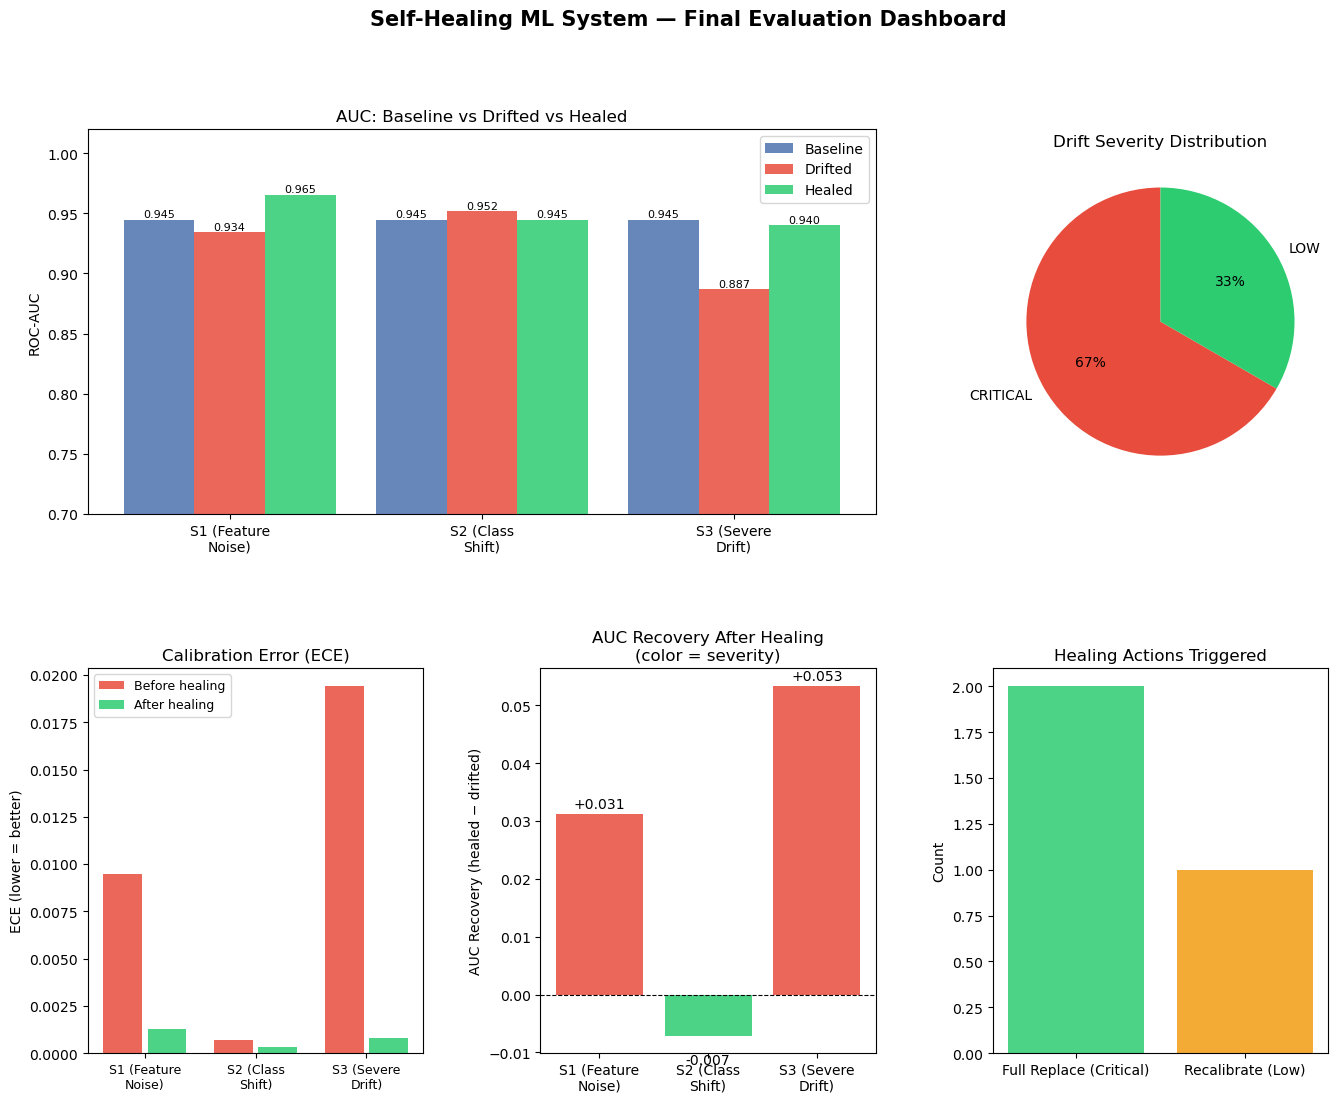

Dashboard saved to outputs/06_final_dashboard.png


In [4]:
# Final dashboard — 5-panel visualization
# ================================================================
# COMPREHENSIVE VISUALIZATION DASHBOARD
# ================================================================
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

scenarios = [r['scenario'] for r in healing_results]
auc_base  = [r['auc_baseline'] for r in healing_results]
auc_drift = [r['auc_before']   for r in healing_results]
auc_healed= [r['auc_after']    for r in healing_results]
ece_before= [r['ece_before']   for r in healing_results]
ece_after = [r['ece_after']    for r in healing_results]
severities= [r['severity']     for r in healing_results]
actions   = [r['healing_action'] for r in healing_results]

short_names = ['S1 (Feature\nNoise)', 'S2 (Class\nShift)', 'S3 (Severe\nDrift)']
x = np.arange(len(scenarios))
width = 0.28
colors_map = {'MODERATE': '#f39c12', 'CRITICAL': '#e74c3c', 'LOW': '#2ecc71'}

# ---- Plot 1: AUC Comparison (grouped bar) ----
ax1 = fig.add_subplot(gs[0, :2])
b1 = ax1.bar(x - width, auc_base,   width, label='Baseline',  color='#4C72B0', alpha=0.85)
b2 = ax1.bar(x,          auc_drift,  width, label='Drifted',   color='#e74c3c', alpha=0.85)
b3 = ax1.bar(x + width,  auc_healed, width, label='Healed',    color='#2ecc71', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(short_names, fontsize=10)
ax1.set_ylabel("ROC-AUC"); ax1.set_title("AUC: Baseline vs Drifted vs Healed")
ax1.set_ylim(0.7, 1.02); ax1.legend()
for bars in [b1, b2, b3]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{bar.get_height():.3f}", ha='center', fontsize=8)

# ---- Plot 2: Severity pie ----
ax2 = fig.add_subplot(gs[0, 2])
from collections import Counter
sev_counts = Counter(severities)
ax2.pie(list(sev_counts.values()), labels=list(sev_counts.keys()),
        colors=[colors_map.get(s,'gray') for s in sev_counts.keys()],
        autopct='%1.0f%%', startangle=90)
ax2.set_title("Drift Severity Distribution")

# ---- Plot 3: ECE Before vs After ----
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(x - 0.2, ece_before, 0.35, label='Before healing', color='#e74c3c', alpha=0.85)
ax3.bar(x + 0.2, ece_after,  0.35, label='After healing',  color='#2ecc71', alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(short_names, fontsize=9)
ax3.set_ylabel("ECE (lower = better)"); ax3.set_title("Calibration Error (ECE)")
ax3.legend(fontsize=9)

# ---- Plot 4: AUC Recovery ----
ax4 = fig.add_subplot(gs[1, 1])
recovery = [r['auc_after'] - r['auc_before'] for r in healing_results]
bar_colors = [colors_map.get(s,'gray') for s in severities]
bars = ax4.bar(short_names, recovery, color=bar_colors, alpha=0.85)
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.set_ylabel("AUC Recovery (healed − drifted)")
ax4.set_title("AUC Recovery After Healing\n(color = severity)")
for bar, val in zip(bars, recovery):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.005,
             f"{val:+.3f}", ha='center', fontsize=10)

# ---- Plot 5: Healing actions ----
ax5 = fig.add_subplot(gs[1, 2])
action_counts = Counter(actions)
action_labels = {'recalibrate': 'Recalibrate (Low)', 
                 'incremental_retrain': 'Incremental Retrain (Med)',
                 'full_replace': 'Full Replace (Critical)'}
ax5.bar([action_labels.get(a, a) for a in action_counts.keys()],
        list(action_counts.values()),
        color=['#2ecc71', '#f39c12', '#e74c3c'][:len(action_counts)], alpha=0.85)
ax5.set_ylabel("Count"); ax5.set_title("Healing Actions Triggered")

plt.suptitle("Self-Healing ML System — Final Evaluation Dashboard", fontsize=15, fontweight='bold')
plt.savefig("outputs/06_final_dashboard.png", dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved to outputs/06_final_dashboard.png")


In [5]:
# Final project report
# ================================================================
# PROJECT SUMMARY REPORT
# ================================================================
total_auc_recovery = np.mean([r['auc_after'] - r['auc_before'] for r in healing_results])
total_ece_reduction = np.mean([r['ece_before'] - r['ece_after'] for r in healing_results])

report = {
    "project": "Confidence-Aware Self-Healing ML System",
    "dataset": "Credit Card Fraud (284807 transactions, 0.17% fraud)",
    "baseline_model": baseline['model_name'],
    "baseline_roc_auc": baseline['roc_auc'],
    "baseline_pr_auc": baseline['pr_auc'],
    "baseline_fraud_recall": baseline['recall_fraud'],
    "split_strategy": "Time-based (not random)",
    "drift_scenarios_tested": len(healing_results),
    "severities_detected": severities,
    "healing_actions_used": actions,
    "avg_auc_recovery": round(float(total_auc_recovery), 4),
    "avg_ece_reduction": round(float(total_ece_reduction), 4),
    "calibration_ece_before": conf_summary['ece_before_calibration'],
    "calibration_ece_after": conf_summary['ece_after_calibration'],
    "ece_improvement_pct": conf_summary['ece_improvement_pct'],
    "healing_actions_defined": {
        "LOW": "Temperature Scaling recalibration",
        "MODERATE": "Incremental RandomForest retrain on new data",
        "CRITICAL": "Full model replacement with fresh training"
    }
}

with open("outputs/final_report.json", "w") as f:
    json.dump(report, f, indent=4)

print("=" * 60)
print("  PROJECT FINAL REPORT")
print("=" * 60)
print(json.dumps(report, indent=2))
print("\nAll outputs saved in outputs/ folder.")


  PROJECT FINAL REPORT
{
  "project": "Confidence-Aware Self-Healing ML System",
  "dataset": "Credit Card Fraud (284807 transactions, 0.17% fraud)",
  "baseline_model": "RandomForest",
  "baseline_roc_auc": 0.9445,
  "baseline_pr_auc": 0.7992,
  "baseline_fraud_recall": 0.6533,
  "split_strategy": "Time-based (not random)",
  "drift_scenarios_tested": 3,
  "severities_detected": [
    "CRITICAL",
    "LOW",
    "CRITICAL"
  ],
  "healing_actions_used": [
    "full_replace",
    "recalibrate",
    "full_replace"
  ],
  "avg_auc_recovery": 0.0258,
  "avg_ece_reduction": 0.0091,
  "calibration_ece_before": 0.0003,
  "calibration_ece_after": 0.0003,
  "ece_improvement_pct": 11.7,
  "healing_actions_defined": {
    "LOW": "Temperature Scaling recalibration",
    "MODERATE": "Incremental RandomForest retrain on new data",
    "CRITICAL": "Full model replacement with fresh training"
  }
}

All outputs saved in outputs/ folder.
